In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

__The below code is for the validation files:__

In [37]:
BASE_PATH = r"C:\Users\Thomas\Documents\GitHub\opendc\output"

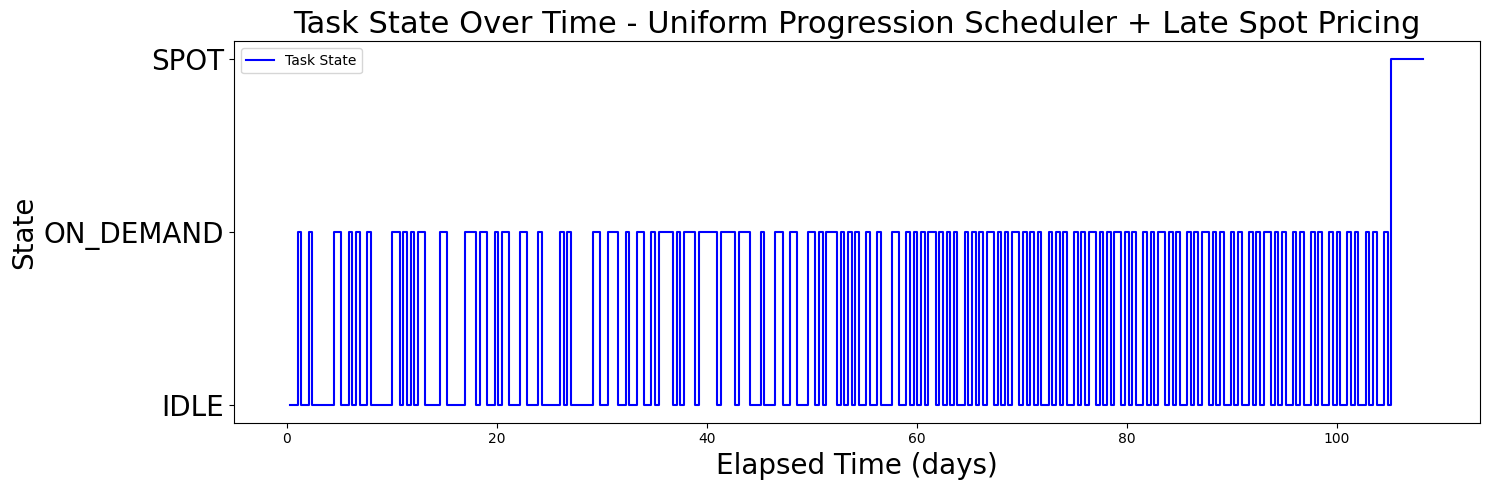

In [ ]:
task_file_path = "uniform_progress_validate/0/seed=0/task.parquet"
task_df = pd.read_parquet(task_file_path)

conditions = [
    (task_df['task_state'] == 'PROVISIONING'),
    (task_df['price_state'] == 'SPOT'),
    (task_df['price_state'] == 'ON_DEMAND')
]

choices = ['IDLE', 'SPOT', 'ON_DEMAND']
task_df['state'] = np.select(conditions, choices, default='UNKNOWN')

task_df['elapsed_time_days'] = task_df['timestamp'] / (30000) * (0.3472)  # convert to days

# set priorities
state_priority = {'SPOT': 3, 'ON_DEMAND': 2, 'IDLE': 1, 'UNKNOWN': 0}
task_df['state_priority'] = task_df['state'].map(state_priority)

# group by elapsed time and select the highest priority state
max_priority_indices = task_df.groupby('elapsed_time_days')['state_priority'].idxmax()
prioritized_states = task_df.loc[max_priority_indices, ['elapsed_time_days', 'state']].drop_duplicates()


fig, ax = plt.subplots(figsize=(15, 5))
prioritized_states['state_y'] = prioritized_states['state'].map({'IDLE': 0, 'ON_DEMAND': 1, 'SPOT': 2})
ax.step(prioritized_states['elapsed_time_days'], prioritized_states['state_y'], where='post', color='blue', label='Task State')
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['IDLE', 'ON_DEMAND', 'SPOT'], fontsize = 20)
ax.set_xlabel('Elapsed Time (days)', fontsize=20)
ax.set_ylabel('State', fontsize=20)
ax.set_title('Task State Over Time - Uniform Progression Scheduler + Late Spot Pricing', fontsize=22)

ax.legend()
plt.tight_layout()
plt.show()


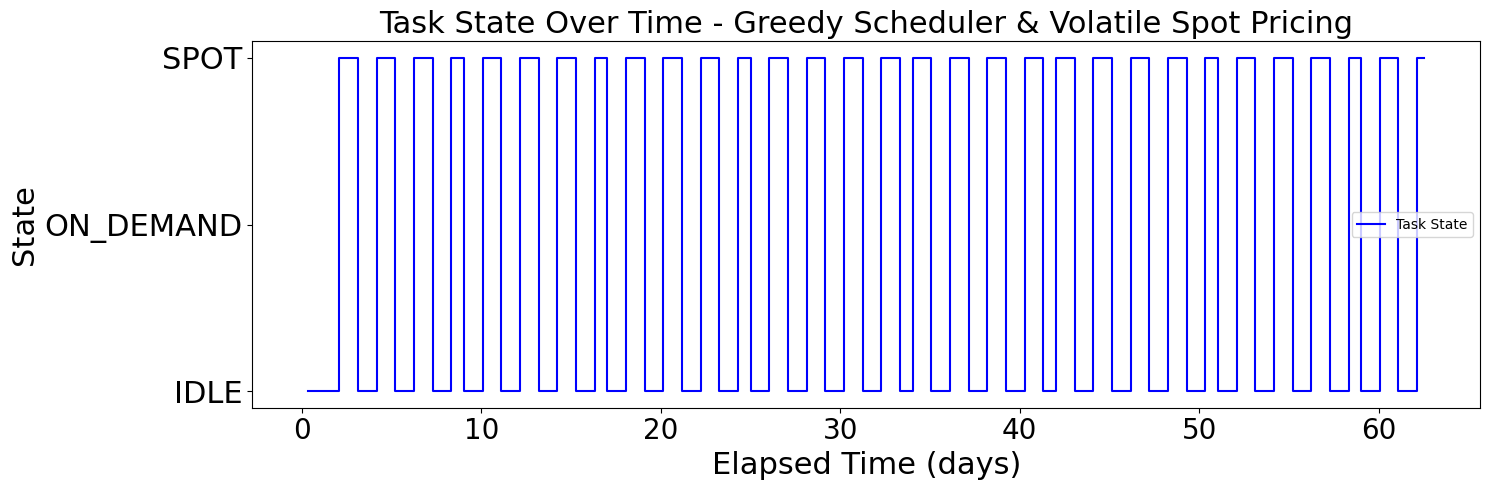

In [ ]:
task_file_path = "greedy_validate/0/seed=0/task.parquet"
task_df = pd.read_parquet(task_file_path)

conditions = [
    (task_df['task_state'] == 'PROVISIONING'),
    (task_df['price_state'] == 'SPOT'),
    (task_df['price_state'] == 'ON_DEMAND')
]
choices = ['IDLE', 'SPOT', 'ON_DEMAND']
task_df['state'] = np.select(conditions, choices, default='UNKNOWN')

task_df['elapsed_time_days'] = task_df['timestamp'] / (30000) * (0.3472)  # convert to days

# set priorities
state_priority = {'SPOT': 3, 'ON_DEMAND': 2, 'IDLE': 1, 'UNKNOWN': 0}
task_df['state_priority'] = task_df['state'].map(state_priority)

# group by elapsed time and select the highest priority state
max_priority_indices = task_df.groupby('elapsed_time_days')['state_priority'].idxmax()
prioritized_states = task_df.loc[max_priority_indices, ['elapsed_time_days', 'state']].drop_duplicates()


fig, ax = plt.subplots(figsize=(15, 5))
prioritized_states['state_y'] = prioritized_states['state'].map({'IDLE': 0, 'ON_DEMAND': 1, 'SPOT': 2})
ax.step(prioritized_states['elapsed_time_days'], prioritized_states['state_y'], where='post', color='blue', label='Task State')
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['IDLE', 'ON_DEMAND', 'SPOT'], fontsize=22)
ax.set_xlabel('Elapsed Time (days)', fontsize=22)
ax.set_ylabel('State', fontsize=22)
ax.set_title('Task State Over Time - Greedy Scheduler & Volatile Spot Pricing', fontsize=22)
ax.tick_params(axis='x', labelsize=20)
ax.legend()
plt.tight_layout()
plt.show()


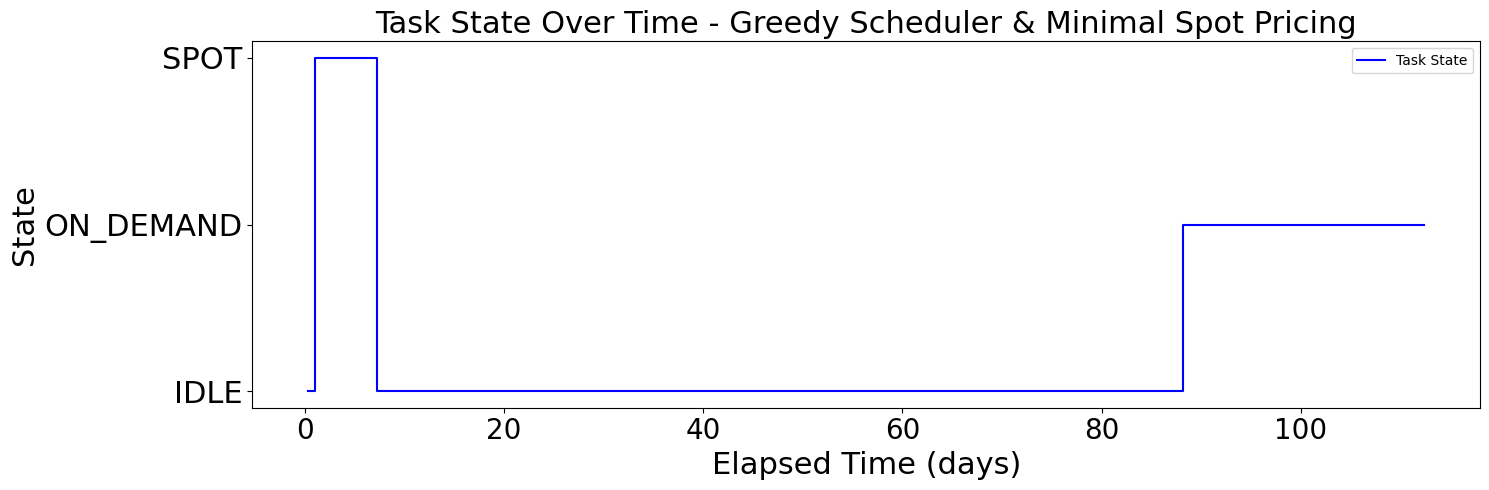

In [ ]:
task_file_path = "uniform_progress_validate/1/seed=0/task.parquet"
task_df = pd.read_parquet(task_file_path)

conditions = [
    (task_df['task_state'] == 'PROVISIONING'),
    (task_df['price_state'] == 'SPOT'),
    (task_df['price_state'] == 'ON_DEMAND')
]
choices = ['IDLE', 'SPOT', 'ON_DEMAND']
task_df['state'] = np.select(conditions, choices, default='UNKNOWN')

task_df['elapsed_time_days'] = task_df['timestamp'] / (30000) * (0.3472)  # convert to days

# set priorities
state_priority = {'SPOT': 3, 'ON_DEMAND': 2, 'IDLE': 1, 'UNKNOWN': 0}
task_df['state_priority'] = task_df['state'].map(state_priority)

# group by elapsed time and select the highest priority state
max_priority_indices = task_df.groupby('elapsed_time_days')['state_priority'].idxmax()
prioritized_states = task_df.loc[max_priority_indices, ['elapsed_time_days', 'state']].drop_duplicates()


fig, ax = plt.subplots(figsize=(15, 5))
prioritized_states['state_y'] = prioritized_states['state'].map({'IDLE': 0, 'ON_DEMAND': 1, 'SPOT': 2})
ax.step(prioritized_states['elapsed_time_days'], prioritized_states['state_y'], where='post', color='blue', label='Task State')
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['IDLE', 'ON_DEMAND', 'SPOT'], fontsize=22)
ax.set_xlabel('Elapsed Time (days)', fontsize=22)
ax.set_ylabel('State', fontsize=22)
ax.set_title('Task State Over Time - Greedy Scheduler & Minimal Spot Pricing', fontsize=22)
ax.tick_params(axis='x', labelsize=20)
ax.legend()
plt.tight_layout()
plt.show()


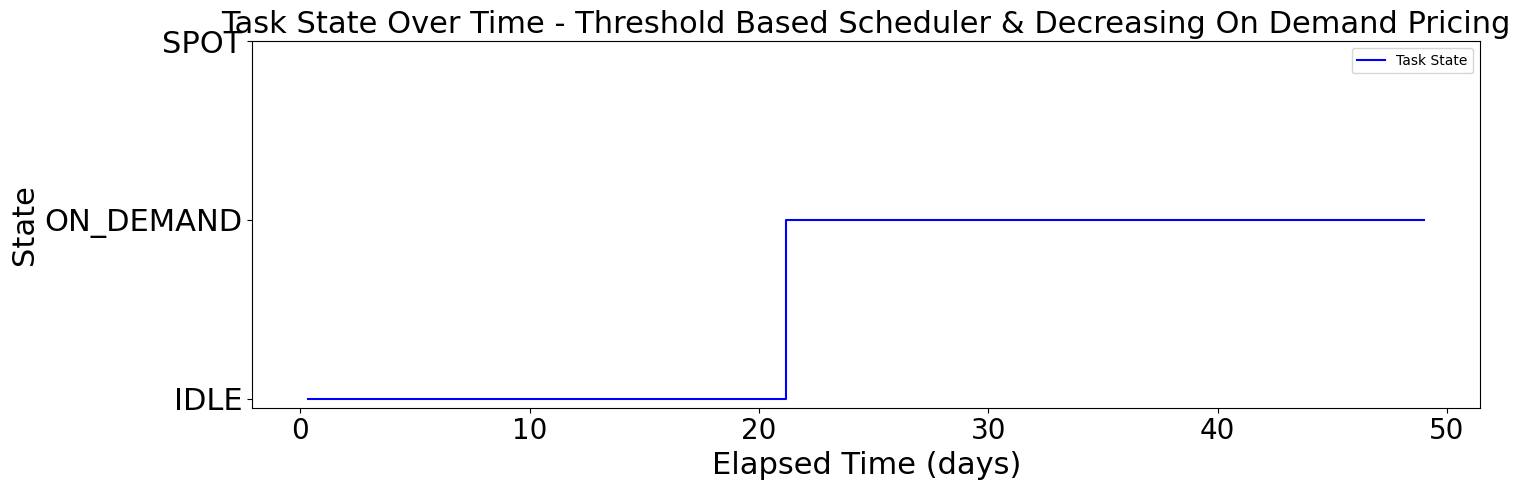

In [ ]:
task_file_path = "radical_price_validate/0/seed=0/task.parquet"
task_df = pd.read_parquet(task_file_path)

conditions = [
    (task_df['task_state'] == 'PROVISIONING'),
    (task_df['price_state'] == 'SPOT'),
    (task_df['price_state'] == 'ON_DEMAND')
]
choices = ['IDLE', 'SPOT', 'ON_DEMAND']
task_df['state'] = np.select(conditions, choices, default='UNKNOWN')

task_df['elapsed_time_days'] = task_df['timestamp'] / (30000) * (0.3472)  # convert to days

# set priorities
state_priority = {'SPOT': 3, 'ON_DEMAND': 2, 'IDLE': 1, 'UNKNOWN': 0}
task_df['state_priority'] = task_df['state'].map(state_priority)

# group by elapsed time and select the highest priority state
max_priority_indices = task_df.groupby('elapsed_time_days')['state_priority'].idxmax()
prioritized_states = task_df.loc[max_priority_indices, ['elapsed_time_days', 'state']].drop_duplicates()


fig, ax = plt.subplots(figsize=(15, 5))
prioritized_states['state_y'] = prioritized_states['state'].map({'IDLE': 0, 'ON_DEMAND': 1, 'SPOT': 2})
ax.step(prioritized_states['elapsed_time_days'], prioritized_states['state_y'], where='post', color='blue', label='Task State')
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['IDLE', 'ON_DEMAND', 'SPOT'], fontsize=22)
ax.set_xlabel('Elapsed Time (days)', fontsize=22)
ax.set_ylabel('State', fontsize=22)
ax.set_title('Task State Over Time - Threshold Based Scheduler & Decreasing On Demand Pricing', fontsize=22)
ax.tick_params(axis='x', labelsize=20)
ax.legend()
plt.tight_layout()
plt.show()


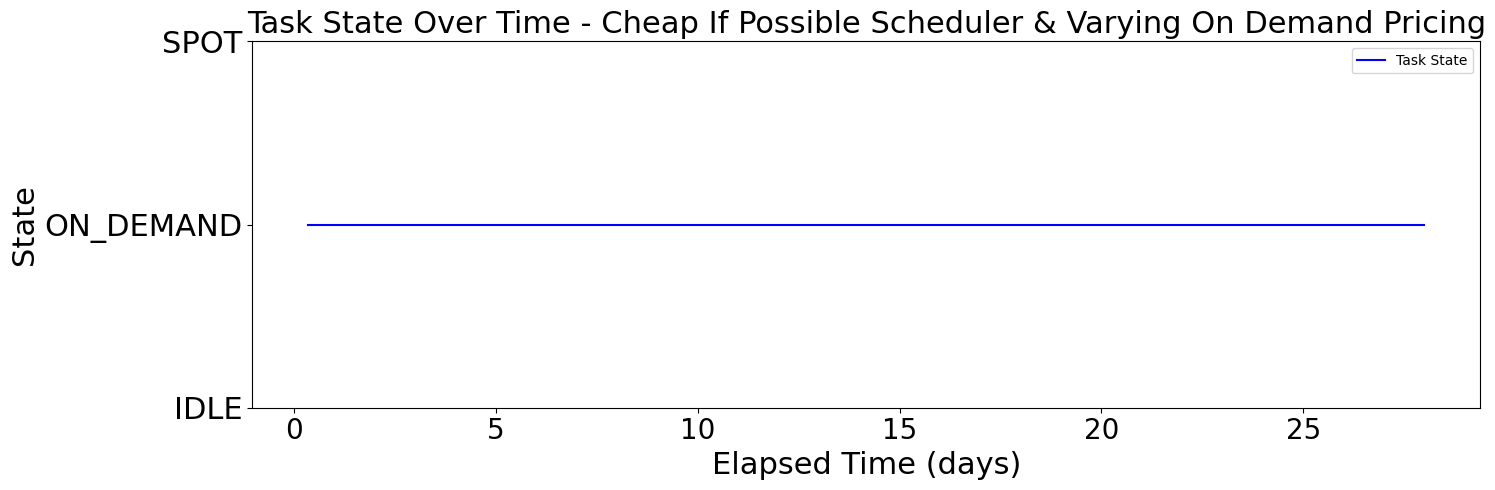

In [ ]:
task_file_path = "price_validate/0/seed=0/task.parquet"
task_df = pd.read_parquet(task_file_path)

conditions = [
    (task_df['task_state'] == 'PROVISIONING'),
    (task_df['price_state'] == 'SPOT'),
    (task_df['price_state'] == 'ON_DEMAND')
]
choices = ['IDLE', 'SPOT', 'ON_DEMAND']
task_df['state'] = np.select(conditions, choices, default='UNKNOWN')

task_df['elapsed_time_days'] = task_df['timestamp'] / (30000) * (0.3472)  # convert to days

# set priorities
state_priority = {'SPOT': 3, 'ON_DEMAND': 2, 'IDLE': 1, 'UNKNOWN': 0}
task_df['state_priority'] = task_df['state'].map(state_priority)

# group by elapsed time and select the highest priority state
max_priority_indices = task_df.groupby('elapsed_time_days')['state_priority'].idxmax()
prioritized_states = task_df.loc[max_priority_indices, ['elapsed_time_days', 'state']].drop_duplicates()


fig, ax = plt.subplots(figsize=(15, 5))
prioritized_states['state_y'] = prioritized_states['state'].map({'IDLE': 0, 'ON_DEMAND': 1, 'SPOT': 2})
ax.step(prioritized_states['elapsed_time_days'], prioritized_states['state_y'], where='post', color='blue', label='Task State')
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['IDLE', 'ON_DEMAND', 'SPOT'], fontsize=22)
ax.set_xlabel('Elapsed Time (days)', fontsize=22)
ax.set_ylabel('State', fontsize=22)
ax.set_title('Task State Over Time - Cheap If Possible Scheduler & Varying On Demand Pricing', fontsize=22)
ax.tick_params(axis='x', labelsize=20)
ax.legend()
plt.tight_layout()
plt.show()


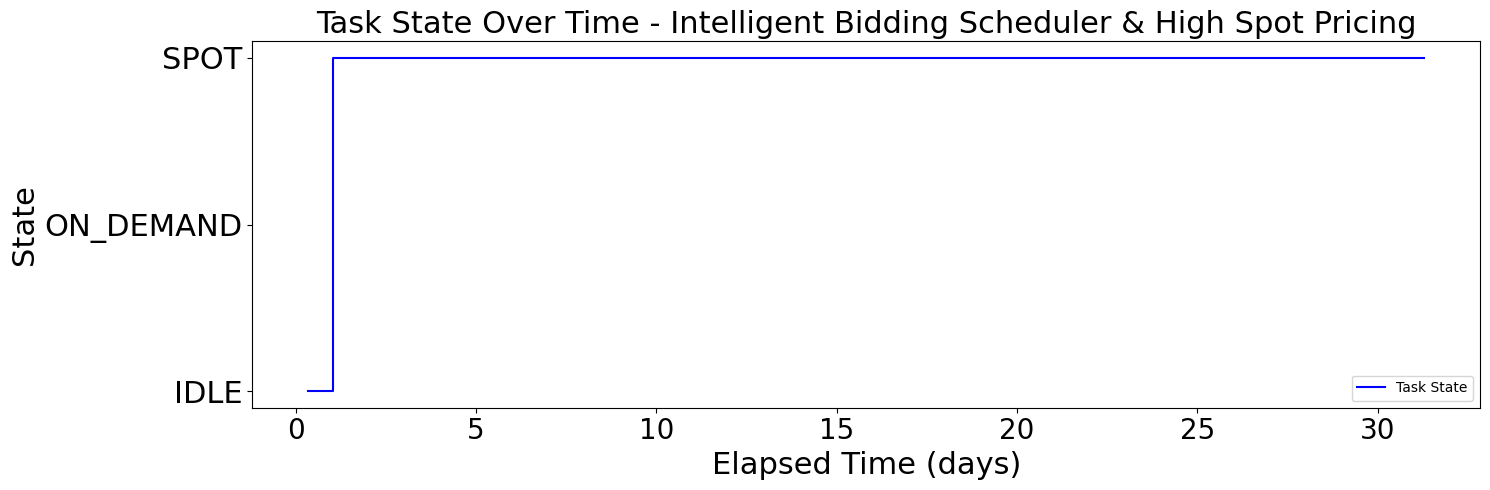

In [ ]:
task_file_path = "intelligent_bidding_validate/0/seed=0/task.parquet"
task_df = pd.read_parquet(task_file_path)

conditions = [
    (task_df['task_state'] == 'PROVISIONING'),
    (task_df['price_state'] == 'SPOT'),
    (task_df['price_state'] == 'ON_DEMAND')
]
choices = ['IDLE', 'SPOT', 'ON_DEMAND']
task_df['state'] = np.select(conditions, choices, default='UNKNOWN')

task_df['elapsed_time_days'] = task_df['timestamp'] / (30000) * (0.3472)  # convert to days

# set priorities
state_priority = {'SPOT': 3, 'ON_DEMAND': 2, 'IDLE': 1, 'UNKNOWN': 0}
task_df['state_priority'] = task_df['state'].map(state_priority)

# group by elapsed time and select the highest priority state
max_priority_indices = task_df.groupby('elapsed_time_days')['state_priority'].idxmax()
prioritized_states = task_df.loc[max_priority_indices, ['elapsed_time_days', 'state']].drop_duplicates()


fig, ax = plt.subplots(figsize=(15, 5))
prioritized_states['state_y'] = prioritized_states['state'].map({'IDLE': 0, 'ON_DEMAND': 1, 'SPOT': 2})
ax.step(prioritized_states['elapsed_time_days'], prioritized_states['state_y'], where='post', color='blue', label='Task State')
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['IDLE', 'ON_DEMAND', 'SPOT'], fontsize=22)
ax.set_xlabel('Elapsed Time (days)', fontsize=22)
ax.set_ylabel('State', fontsize=22)
ax.set_title('Task State Over Time - Intelligent Bidding Scheduler & High Spot Pricing', fontsize=22)
ax.tick_params(axis='x', labelsize=20)
ax.legend()
plt.tight_layout()
plt.show()
